# Análisis de la Encuesta de Competencias Financieras 2021

¿Es necesario adaptar nuestras ofertas actuales o crear nuevas en función de las tendencias nacionales en comportamiento financiero y competencias financieras?

## Librerias

In [4]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

from pathlib import Path
from scipy.stats import chi2_contingency
import statsmodels.api as sm
import statsmodels.formula.api as smf

## Carga del fichero csv

In [5]:
df = pd.read_csv(
    r"..\Data\Silver_ECF_090226.csv",
    sep=","
)
df.shape

(7554, 26)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7554 entries, 0 to 7553
Data columns (total 26 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   cat_educacion       7554 non-null   object 
 1   estado_laboral      7554 non-null   object 
 2   familia             7554 non-null   object 
 3   riq_inmob           7554 non-null   object 
 4   ahorro              7554 non-null   int64  
 5   deuda               7554 non-null   int64  
 6   adq_ahorro2         7554 non-null   int64  
 7   adq_deuda2          7554 non-null   int64  
 8   adq_otro            7554 non-null   int64  
 9   ahorra_12m          7554 non-null   int64  
 10  consumo_ahorros     7554 non-null   int64  
 11  cred_inf            7554 non-null   int64  
 12  cred_form           7554 non-null   int64  
 13  cred_add            7554 non-null   int64  
 14  impago              7554 non-null   int64  
 15  ayudas              7554 non-null   int64  
 16  rechaz

In [7]:
df.head()

,cat_educacion,estado_laboral,familia,riq_inmob,ahorro,deuda,adq_ahorro2,adq_deuda2,adq_otro,ahorra_12m,...,rechazo,semirechazo,nopiden,age,ID,year,inflacion_ok,interes_comp_ok,diversificacion_ok,weight
0,Universidad,Asalariado,Vive con pareja,Solo residencia principal,0,1,0,1,1,1,...,0,0,0,40,1,2022,0,0,-1,6814.1260
1,Universidad,Asalariado,Otros adultos,Residencia principal y otras,0,1,0,0,0,0,...,0,0,1,54,2,2022,1,-1,-1,3277.0151
2,Educación Secundaria,Asalariado,Vive solo,Residencia principal y otras,1,0,1,0,1,1,...,0,0,0,54,3,2022,1,1,1,1730.8894
3,Educación Secundaria,Asalariado,Vive con pareja,Solo residencia principal,1,1,0,0,0,1,...,0,0,0,48,4,2022,0,0,-1,3449.5601
4,Educación Primaria,Asalariado,Otros adultos,Solo residencia principal,0,1,0,1,1,0,...,0,0,0,49,5,2022,1,-1,-1,2644.1462


In [8]:
df.columns.tolist()

['cat_educacion',
 'estado_laboral',
 'familia',
 'riq_inmob',
 'ahorro',
 'deuda',
 'adq_ahorro2',
 'adq_deuda2',
 'adq_otro',
 'ahorra_12m',
 'consumo_ahorros',
 'cred_inf',
 'cred_form',
 'cred_add',
 'impago',
 'ayudas',
 'rechazo',
 'semirechazo',
 'nopiden',
 'age',
 'ID',
 'year',
 'inflacion_ok',
 'interes_comp_ok',
 'diversificacion_ok',
 'weight']

## 1. Transformación del dataset (Gold)

### 1.1. Creación de grupos de edad

In [9]:
def make_age_group(s: pd.Series) -> pd.Categorical:
    bins = [18, 35, 45, 55, 65, 81]
    labels = ["18-34 años", "35-44 años", "45-54 años", "55-64 años", "65-79 años"]
    return pd.cut(s, bins=bins, right=False, labels=labels, include_lowest=True)

### 1.2. Función de transformación de variables binarias (0/1)

In [10]:
def to_binary01(x) -> float:
    """
    Универсальный перевод в 0/1:
    - 1/0, True/False → 1/0
    - 'sí'/'si'/'yes'/'y' → 1, 'no'/'n' → 0
    - '1'/'0' строки → 1/0
    - NaN остаётся NaN
    Если у тебя коды 1/2 (например 1=Sí, 2=No), просто добавь их ниже.
    """
    if pd.isna(x):
        return np.nan

    # booleans
    if isinstance(x, (bool, np.bool_)):
        return float(int(x))

    # numbers
    if isinstance(x, (int, np.integer, float, np.floating)):
        # часто встречается 1/0
        if x in (0, 1):
            return float(x)
        # часто встречается 1/2 (1=Sí, 2=No)
        if x == 2:
            return 0.0
        if x == 1:
            return 1.0
        # иначе неизвестно
        return np.nan

    # strings
    s = str(x).strip().lower()
    yes = {"si", "sí", "yes", "y", "true", "t", "1"}
    no  = {"no", "n", "false", "f", "0"}

    if s in yes:
        return 1.0
    if s in no:
        return 0.0

    return np.nan

### 1.2. Función de resumen de pesos por grupo

In [11]:

def summarize_binary_shares(df: pd.DataFrame, group_cols: list[str], bin_cols: list[str]) -> pd.DataFrame:
    tmp = df[group_cols + bin_cols].copy()

    # доли
    tab = (
        tmp
        .groupby(group_cols, dropna=False)
        .agg({c: "mean" for c in bin_cols} | {"__N__": ("__N__", "size")} if "__N__" in tmp.columns else {})
    )

    if "__N__" not in tab.columns:
        tab["N"] = tmp.groupby(group_cols, dropna=False).size()
    else:
        tab = tab.rename(columns={"__N__": "N"})

    for c in bin_cols:
        tab[c] = (tab[c] * 100).round(1)

    tab = tab.reset_index()
    return tab


### 1.3. Agrupación de variables 

In [ ]:
# Соц-дем (страты)
STRATA_COLS = ["cat_educacion", "estado_laboral", "familia", "riq_inmob"]

# Поведение (то, что нужно для пункта 2)
BEHAVIOR_COLS = [
    "ahorro", "deuda",
    "adq_ahorro2", "adq_deuda2", "adq_otro",
    "ahorra_12m",
    "consumo_ahorros",
    "cred_inf", "cred_form", "cred_add",
    "impago",
    "ayudas",
    "rechazo", "semirechazo", "nopiden"
]

ALL_NEEDED = ["age"] + STRATA_COLS + BEHAVIOR_COLS

### 1.4. Preparación del dataframe con pesos

In [12]:
WEIGHT_COL = "weight"

df = df.copy()
df.columns = df.columns.str.strip()

missing = [c for c in ALL_NEEDED if c not in df.columns]
if missing:
    print("⚠️ No hay columnas en df:", missing)

need_cols = [c for c in ALL_NEEDED if c in df.columns]
if WEIGHT_COL in df.columns:
    need_cols = list(dict.fromkeys(need_cols + [WEIGHT_COL]))  # без дублей, сохраняет порядок

NameError: name 'ALL_NEEDED' is not defined

### 1.5. Creación del dataframe 

In [ ]:
work = df[need_cols].copy()
work["age"] = pd.to_numeric(work["age"], errors="coerce")
work["edad_grupo"] = make_age_group(work["age"])

## 2. Indicador de competencia

Utilizar tres preguntas sobre alfabetización (inflación, interés compuesto, diversificación).
Generar:
- Puntuación individual
- Categorías: bajo / medio / alto nivel

Objetivo: Comprender si el conocimiento es suficiente para productos financieros complejos.

### 2.1. Puntuación individual (0-3)

Las respuestas computan puntos de la siguiente forma:

- Respuesta correcta → 1 punto
- Incorrecta → 0 puntos
- No sabe / no contesta (-1) → la tratamos como incorrecta o como missing
  
Lo más habitual en indicadores de alfabetización financiera es:

- Contar solo las correctas (+1)
- Tratar 0 y -1 como “no suma puntos”
  
Así que la puntuación total irá de 0 a 3.

In [6]:
# Aseguramos que -1 no suma (lo tratamos como 0 en el score)
cols_comp = ["inflacion_ok", "interes_comp_ok", "diversificacion_ok"]

# Reemplazamos -1 por 0 SOLO para el cálculo del score
df_comp = df[cols_comp].replace(-1, 0)

# Creamos la puntuación: suma de respuestas correctas
df["score_comp_fin"] = df_comp.sum(axis=1)

### 2.2. Indicador categórico (bajo/medio/alto)

In [7]:
def categorizar_competencia(score):
    if score <= 1:
        return "bajo"
    elif score == 2:
        return "medio"
    else:  # score == 3
        return "alto"

df["nivel_comp_fin"] = df["score_comp_fin"].apply(categorizar_competencia)

In [8]:
# Vemos como queda distribuido por categorias
df["score_comp_fin"].value_counts().sort_index()
df["nivel_comp_fin"].value_counts()

nivel_comp_fin
bajo     3342
medio    2646
alto     1566
Name: count, dtype: int64

In [9]:
df["nivel_comp_fin"].value_counts(normalize=True)

nivel_comp_fin
bajo     0.442415
medio    0.350278
alto     0.207307
Name: proportion, dtype: float64

### 2.3. Indicador categórico binario
- competente = score ≥ 2
- no competente = score ≤ 1

In [10]:
df["comp_fin_bin"] = (df["score_comp_fin"] >= 2).astype(int)

### 2.4. Visualizaciones

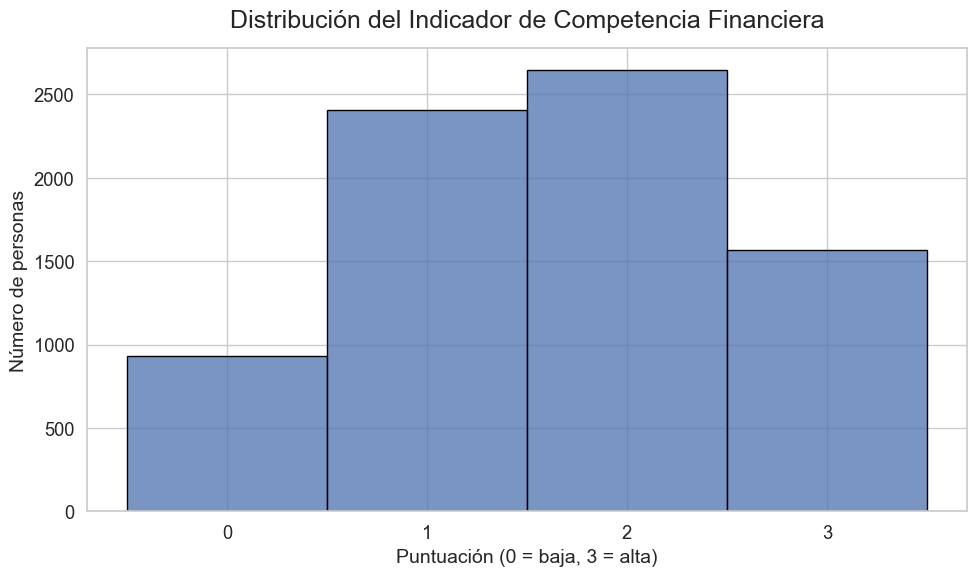

In [ ]:
# Estilo general
sns.set(style="whitegrid", palette="deep", font_scale=1.2)

plt.figure(figsize=(10,6))

# Histograma
sns.histplot(
    data=df,
    x="score_comp_fin",
    bins=[-0.5, 0.5, 1.5, 2.5, 3.5],  # para separar bien 0,1,2,3
    color="#4C72B0",
    kde=False,
    edgecolor="black"
)

# Títulos y etiquetas
plt.title("Distribución del Indicador de Competencia Financiera", fontsize=18, pad=15)
plt.xlabel("Puntuación (0 = baja, 3 = alta)", fontsize=14)
plt.ylabel("Número de personas", fontsize=14)

# Ajustes finales
plt.xticks([0,1,2,3])
plt.tight_layout()
plt.show()

C:\Users\edo\AppData\Local\Temp\ipykernel_2644\2542247705.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


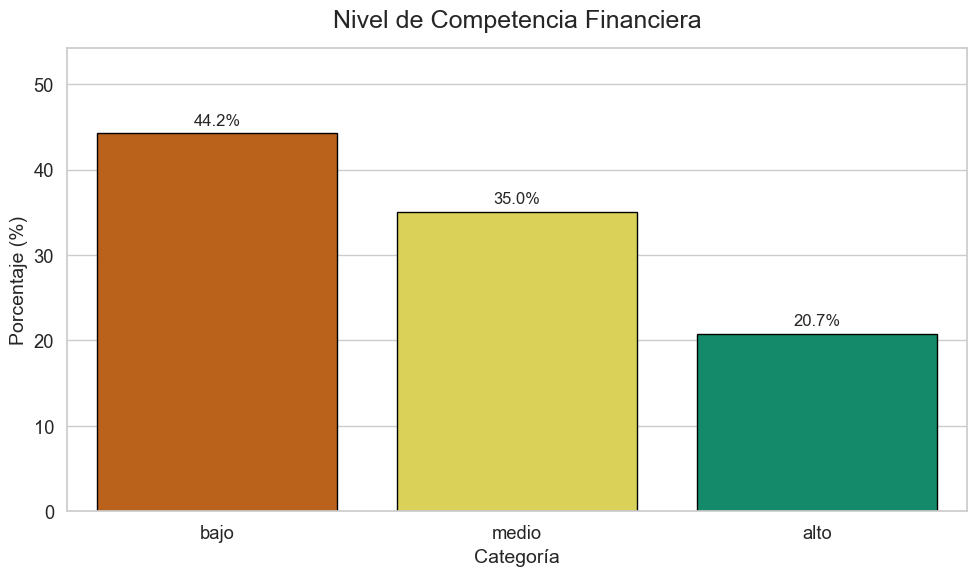

In [96]:

sns.set(style="whitegrid", font_scale=1.2)

# Orden lógico
orden = ["bajo", "medio", "alto"]

# Calcular porcentajes
porc = (
    df["nivel_comp_fin"]
    .value_counts(normalize=True)
    .reindex(orden)
    * 100
)

plt.figure(figsize=(10,6))

sns.barplot(
    x=porc.index,
    y=porc.values,
    palette=["#D55E00", "#F0E442", "#009E73"],  # rojo → amarillo → verde
    edgecolor="black"
)

plt.title("Nivel de Competencia Financiera", fontsize=18, pad=15)
plt.xlabel("Categoría", fontsize=14)
plt.ylabel("Porcentaje (%)", fontsize=14)

# Etiquetas encima de cada barra
for i, v in enumerate(porc.values):
    plt.text(i, v + 1, f"{v:.1f}%", ha="center", fontsize=12)

plt.ylim(0, porc.max() + 10)
plt.tight_layout()
plt.show()

C:\Users\edo\AppData\Local\Temp\ipykernel_2644\2705371866.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


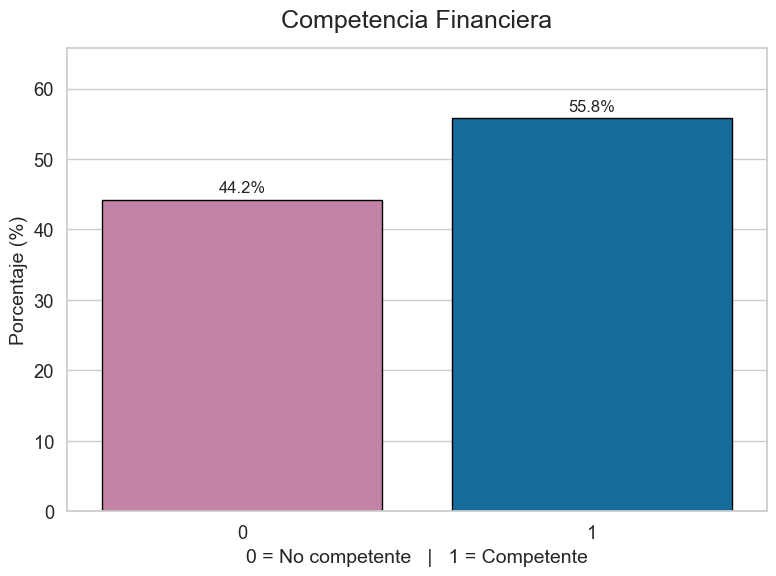

In [99]:
plt.figure(figsize=(8,6))

# Calcular porcentajes
porc_bin = (
    df["comp_fin_bin"]
    .value_counts(normalize=True)
    .sort_index()
    * 100
)

sns.barplot(
    x=porc_bin.index,
    y=porc_bin.values,
    palette=["#CC79A7", "#0072B2"],  # dos colores contrastados
    edgecolor="black"
)

plt.title("Competencia Financiera", fontsize=18, pad=15)
plt.xlabel("0 = No competente   |   1 = Competente", fontsize=14)
plt.ylabel("Porcentaje (%)", fontsize=14)

# Etiquetas encima de cada barra
for i, v in enumerate(porc_bin.values):
    plt.text(i, v + 1, f"{v:.1f}%", ha="center", fontsize=12)

plt.ylim(0, porc_bin.max() + 10)
plt.tight_layout()
plt.show()

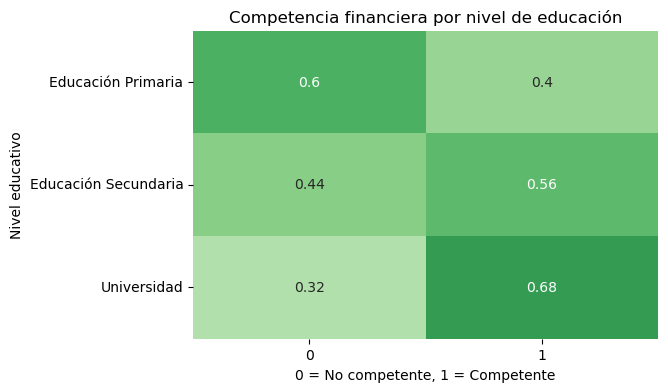

In [13]:
tabla_edu_comp = pd.crosstab(
    df["cat_educacion"],
    df["comp_fin_bin"],
    normalize="index"
)

plt.figure(figsize=(6,4))
sns.heatmap(
    tabla_edu_comp,
    annot=True,
    cmap="Greens",
    vmin=0,
    vmax=1,
    cbar=False
)

plt.title("Competencia financiera por nivel de educación")
plt.xlabel("0 = No competente, 1 = Competente")
plt.ylabel("Nivel educativo")

plt.show()

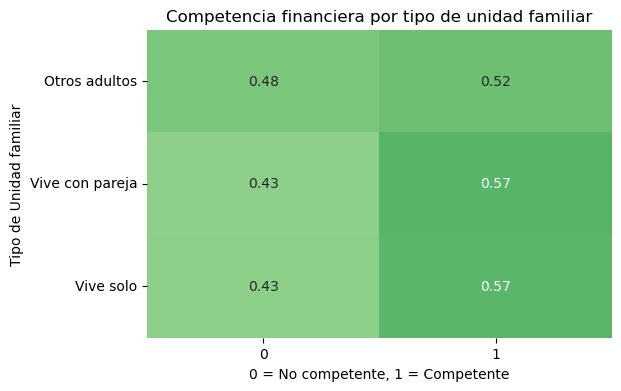

In [15]:
tabla_fam_comp = pd.crosstab(
    df["familia"],
    df["comp_fin_bin"],
    normalize="index"
)

plt.figure(figsize=(6,4))
ax = sns.heatmap(
    tabla_fam_comp,
    annot=True,
    cmap="Greens",
    vmin=0,
    vmax=1,
    cbar=False
)

plt.title("Competencia financiera por tipo de unidad familiar")
plt.xlabel("0 = No competente, 1 = Competente")
plt.ylabel("Tipo de Unidad familiar")

# Rotar etiquetas del eje Y para que se lean horizontalmente
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)

plt.show()

In [18]:
tabla_edad_comp = pd.crosstab(
    df["edad"],
    df["comp_fin_bin"],
    normalize="index"
)

plt.figure(figsize=(6,4))
ax = sns.heatmap(
    tabla_edad_comp,
    annot=True,
    cmap="Greens",
    vmin=0,
    vmax=1,
    cbar=False
)

plt.title("Competencia financiera por grupo de edad")
plt.xlabel("0 = No competente, 1 = Competente")
plt.ylabel("Grupo de edad")

# Forzar etiquetas horizontales en el eje Y
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, ha="right")

plt.show()


KeyError: 'edad'

## 3. Indicadores de Comportamiento real
- Propiedad del producto (t_alahoc, t_alhip)
- Compras en 2 años (a_alahoc, a_alprodc)
- Ahorros en 12 meses
- Comportamiento crediticio

Objetivo: Comprender qué hace realmente la población, no solo qué sabe.

In [3]:
df = pd.read_csv(
    path,
    encoding="utf-8"
)

df.head()

NameError: name 'pd' is not defined

### 3.2. Conversión de variables de comportamiento a binarias

In [ ]:
for c in [col for col in BEHAVIOR_COLS if col in work.columns]:
    work[c] = work[c].map(to_binary01)

work 


,age,cat_educacion,estado_laboral,familia,riq_inmob,ahorro,deuda,adq_ahorro2,adq_deuda2,adq_otro,...,cred_inf,cred_form,cred_add,impago,ayudas,rechazo,semirechazo,nopiden,weight,edad_grupo
0,40,Universidad,Asalariado,Vive con pareja,Solo residencia principal,0.0,1.0,0.0,1.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,6814.12600,35-44 años
1,54,Universidad,Asalariado,Otros adultos,Residencia principal y otras,0.0,1.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,3277.01510,45-54 años
2,54,Educación Secundaria,Asalariado,Vive solo,Residencia principal y otras,1.0,0.0,1.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1730.88940,45-54 años
3,48,Educación Secundaria,Asalariado,Vive con pareja,Solo residencia principal,1.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3449.56010,45-54 años
4,49,Educación Primaria,Asalariado,Otros adultos,Solo residencia principal,0.0,1.0,0.0,1.0,1.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,2644.14620,45-54 años
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7549,26,Universidad,Asalariado,Vive con pareja,No posee residencia principal,1.0,0.0,1.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2670.04570,18-34 años
7550,29,Universidad,Asalariado,Otros adultos,Residencia principal y otras,1.0,0.0,1.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2606.26050,18-34 años
7551,68,Universidad,Jubilado,Vive con pareja,Residencia principal y otras,1.0,0.0,1.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5450.50980,65-79 años
7552,62,Educación Primaria,Autónomo,Vive con pareja,Residencia principal y otras,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,920.34375,55-64 años


### 3.3. Tabla de comportamiento por grupos de edad

In [ ]:
behavior_by_age = (
    work
    .groupby("edad_grupo", dropna=False)[[c for c in BEHAVIOR_COLS if c in work.columns]]
    .mean()
    .mul(100)
    .round(1)
)
behavior_by_age["N"] = work.groupby("edad_grupo", dropna=False).size()
behavior_by_age = behavior_by_age.reset_index()

behavior_by_age

/var/folders/x4/lwd5ns853f3_vz1_y07hfb580000gn/T/ipykernel_40355/1374048298.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("edad_grupo", dropna=False)[[c for c in BEHAVIOR_COLS if c in work.columns]]
/var/folders/x4/lwd5ns853f3_vz1_y07hfb580000gn/T/ipykernel_40355/1374048298.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  behavior_by_age["N"] = work.groupby("edad_grupo", dropna=False).size()


,edad_grupo,ahorro,deuda,adq_ahorro2,adq_deuda2,adq_otro,ahorra_12m,consumo_ahorros,cred_inf,cred_form,cred_add,impago,ayudas,rechazo,semirechazo,nopiden,N
0,18-34 años,30.0,22.5,24.3,18.4,51.8,88.5,13.1,8.0,3.0,2.3,2.8,0.3,3.9,2.1,2.7,1867
1,35-44 años,44.8,63.3,23.6,29.3,59.0,79.2,12.3,8.1,3.5,1.4,3.3,0.3,3.0,1.9,2.2,1401
2,45-54 años,50.5,60.6,22.4,23.9,53.1,72.3,14.3,7.8,3.5,1.9,2.8,1.1,3.8,1.7,2.9,1712
3,55-64 años,53.2,40.2,20.5,16.7,43.8,63.5,13.9,6.0,3.4,1.8,2.7,0.5,3.0,1.4,1.9,1427
4,65-79 años,44.6,22.3,15.4,8.5,28.8,55.0,12.0,3.7,1.9,1.7,1.7,0.5,1.0,0.4,1.0,1147


### 3.4. Tabla de comportamiento por edad y estrato social

In [ ]:
if "cat_educacion" in work.columns:
    behavior_by_age_educ = (
        work
        .groupby(["edad_grupo", "cat_educacion"], dropna=False)[[c for c in BEHAVIOR_COLS if c in work.columns]]
        .mean()
        .mul(100)
        .round(1)
    )
    behavior_by_age_educ["N"] = work.groupby(["edad_grupo", "cat_educacion"], dropna=False).size()
    behavior_by_age_educ = behavior_by_age_educ.reset_index()
    display(behavior_by_age_educ)

/var/folders/x4/lwd5ns853f3_vz1_y07hfb580000gn/T/ipykernel_40355/4268614503.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(["edad_grupo", "cat_educacion"], dropna=False)[[c for c in BEHAVIOR_COLS if c in work.columns]]
/var/folders/x4/lwd5ns853f3_vz1_y07hfb580000gn/T/ipykernel_40355/4268614503.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  behavior_by_age_educ["N"] = work.groupby(["edad_grupo", "cat_educacion"], dropna=False).size()


,edad_grupo,cat_educacion,ahorro,deuda,adq_ahorro2,adq_deuda2,adq_otro,ahorra_12m,consumo_ahorros,cred_inf,cred_form,cred_add,impago,ayudas,rechazo,semirechazo,nopiden,N
0,18-34 años,Educación Primaria,17.9,26.5,18.2,19.9,46.4,77.1,21.4,16.4,4.8,3.6,6.0,0.6,6.2,2.1,6.2,336
1,18-34 años,Educación Secundaria,26.5,16.3,20.7,14.4,47.2,90.1,11.0,7.6,2.9,2.9,2.6,0.4,4.4,2.6,2.4,699
2,18-34 años,Universidad,37.9,26.1,29.8,21.0,57.9,91.8,11.5,4.9,2.4,1.3,1.7,0.1,2.4,1.7,1.4,832
3,35-44 años,Educación Primaria,24.9,57.5,11.6,25.4,47.4,66.2,13.6,13.6,4.0,1.2,7.8,0.9,5.2,2.6,5.5,346
4,35-44 años,Educación Secundaria,39.0,63.2,18.2,33.3,57.2,74.8,16.4,10.4,5.0,2.8,3.1,0.0,4.7,3.5,2.5,318
5,35-44 años,Universidad,56.6,66.1,31.5,29.3,65.3,87.2,9.9,4.6,2.6,0.8,1.2,0.1,1.2,0.8,0.5,737
6,45-54 años,Educación Primaria,28.1,55.7,8.6,23.7,41.4,58.3,16.2,12.4,4.0,1.4,5.1,1.9,6.6,3.3,5.1,573
7,45-54 años,Educación Secundaria,49.3,63.5,17.7,28.4,53.9,71.3,16.5,11.0,5.2,2.9,2.6,0.9,3.5,0.9,2.3,345
8,45-54 años,Universidad,67.1,62.8,34.5,22.0,61.2,82.9,11.8,3.1,2.4,1.9,1.3,0.5,1.9,0.9,1.6,794
9,55-64 años,Educación Primaria,32.4,35.1,9.4,14.0,31.5,48.3,15.3,9.3,3.1,1.8,3.6,0.7,3.6,1.6,2.6,615


### 3.5. Indicadores compuestos de "comportamiento real"

#### 3.5.1. Indice de estrés financiero

In [ ]:
stress_cols = [c for c in ["consumo_ahorros", "cred_inf", "cred_form", "cred_add", "impago", "ayudas"] if c in work.columns]
work["idx_estres_financiero"] = work[stress_cols].sum(axis=1, min_count=1)

#### 3.5.2. Índice de uso de crédito

In [ ]:
credit_cols = [c for c in ["deuda", "adq_deuda2", "cred_form", "cred_add"] if c in work.columns]
work["idx_uso_credito"] = work[credit_cols].sum(axis=1, min_count=1)

#### 3.5.3. Índice de de ahorro

In [ ]:
save_cols = [c for c in ["ahorro", "adq_ahorro2", "ahorra_12m"] if c in work.columns]
work["idx_ahorro"] = work[save_cols].sum(axis=1, min_count=1)


### 3.6. Visualizaciones

In [ ]:

composite_by_age = (
    work
    .groupby("edad_grupo", dropna=False)[["idx_estres_financiero", "idx_uso_credito", "idx_ahorro"]]
    .mean()
    .round(2)
)
composite_by_age["N"] = work.groupby("edad_grupo", dropna=False).size()
composite_by_age = composite_by_age.reset_index()

display(composite_by_age)


/var/folders/x4/lwd5ns853f3_vz1_y07hfb580000gn/T/ipykernel_40355/2111634170.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("edad_grupo", dropna=False)[["idx_estres_financiero", "idx_uso_credito", "idx_ahorro"]]
/var/folders/x4/lwd5ns853f3_vz1_y07hfb580000gn/T/ipykernel_40355/2111634170.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  composite_by_age["N"] = work.groupby("edad_grupo", dropna=False).size()


,edad_grupo,idx_estres_financiero,idx_uso_credito,idx_ahorro,N
0,18-34 años,0.30,0.46,1.43,1867
1,35-44 años,0.29,0.97,1.48,1401
2,45-54 años,0.31,0.90,1.45,1712
3,55-64 años,0.28,0.62,1.37,1427
4,65-79 años,0.22,0.34,1.15,1147


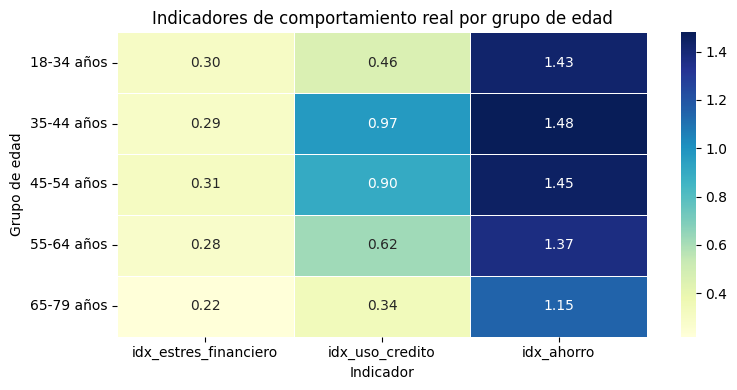

In [ ]:

# убираем N из визуализации
heatmap_data = composite_by_age.set_index("edad_grupo")[[
    "idx_estres_financiero",
    "idx_uso_credito",
    "idx_ahorro"
]]

plt.figure(figsize=(8, 4))

sns.heatmap(
    heatmap_data,
    annot=True,        # показывать числа
    fmt=".2f",
    cmap="YlGnBu",     # палитра
    linewidths=0.5
)

plt.title("Indicadores de comportamiento real por grupo de edad")
plt.ylabel("Grupo de edad")
plt.xlabel("Indicador")

plt.tight_layout()
plt.show()


In [ ]:
def make_pivot_index(df, group_col):
    """
    Строит сводную таблицу:
    group_col vs поведенческие индексы
    """

    tab = (
        df
        .groupby(group_col)[
            ["idx_estres_financiero",
             "idx_uso_credito",
             "idx_ahorro"]
        ]
        .mean()
        .round(2)
    )

    # Добавим размер группы
    tab["N"] = df.groupby(group_col).size()

    return tab.reset_index()


In [ ]:
pivot_educ = make_pivot_index(work, "cat_educacion")
display(pivot_educ)


,cat_educacion,idx_estres_financiero,idx_uso_credito,idx_ahorro,N
0,Educación Primaria,0.37,0.60,0.93,2514
1,Educación Secundaria,0.31,0.65,1.37,1884
2,Universidad,0.20,0.74,1.77,3156


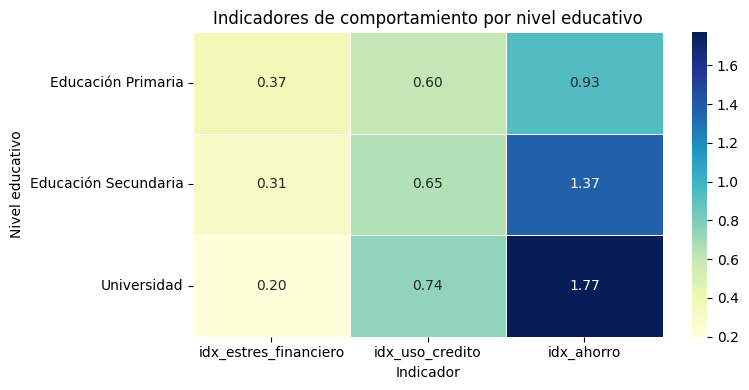

In [ ]:
heat_data = pivot_educ.set_index("cat_educacion")[
    ["idx_estres_financiero", "idx_uso_credito", "idx_ahorro"]
]

plt.figure(figsize=(8, 4))

sns.heatmap(
    heat_data,
    annot=True,
    cmap="YlGnBu",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Indicadores de comportamiento por nivel educativo")
plt.ylabel("Nivel educativo")
plt.xlabel("Indicador")
plt.tight_layout()
plt.show()


In [ ]:
pivot_laboral = make_pivot_index(work, "estado_laboral")
display(pivot_laboral)


,estado_laboral,idx_estres_financiero,idx_uso_credito,idx_ahorro,N
0,Asalariado,0.26,0.86,1.57,3733
1,Autónomo,0.28,0.83,1.59,844
2,Desempleado,0.49,0.47,0.99,780
3,Jubilado,0.20,0.39,1.20,1060
4,Otros inactivos,0.30,0.32,1.10,1137


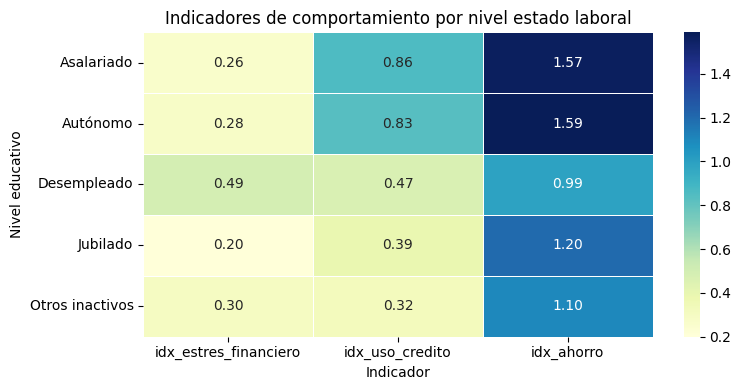

In [ ]:
heat_data = pivot_laboral.set_index("estado_laboral")[
    ["idx_estres_financiero", "idx_uso_credito", "idx_ahorro"]
]

plt.figure(figsize=(8, 4))

sns.heatmap(
    heat_data,
    annot=True,
    cmap="YlGnBu",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Indicadores de comportamiento por nivel estado laboral")
plt.ylabel("Nivel educativo")
plt.xlabel("Indicador")
plt.tight_layout()
plt.show()


In [ ]:
pivot_familia = make_pivot_index(work, "familia")
display(pivot_familia)


,familia,idx_estres_financiero,idx_uso_credito,idx_ahorro,N
0,Otros adultos,0.28,0.37,1.26,1787
1,Vive con pareja,0.28,0.79,1.43,4812
2,Vive solo,0.31,0.63,1.43,955


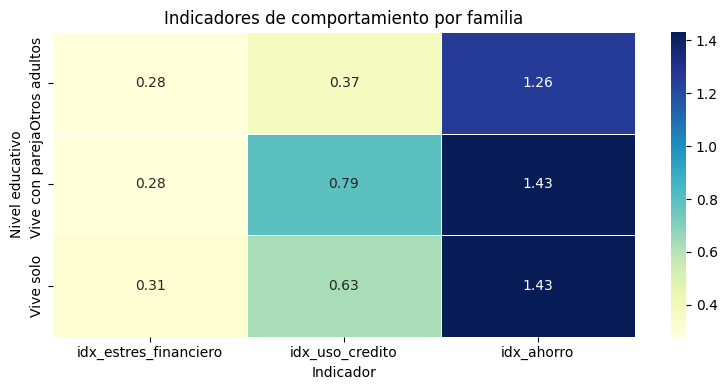

In [ ]:
heat_data = pivot_familia.set_index("familia")[
    ["idx_estres_financiero", "idx_uso_credito", "idx_ahorro"]
]

plt.figure(figsize=(8, 4))

sns.heatmap(
    heat_data,
    annot=True,
    cmap="YlGnBu",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Indicadores de comportamiento por familia")
plt.ylabel("Nivel educativo")
plt.xlabel("Indicador")
plt.tight_layout()
plt.show()


In [ ]:
pivot_inmob = make_pivot_index(work, "riq_inmob")
display(pivot_inmob)


,riq_inmob,idx_estres_financiero,idx_uso_credito,idx_ahorro,N
0,No posee residencia principal,0.45,0.59,1.21,1748
1,Residencia principal y otras,0.20,0.62,1.61,2847
2,Solo residencia principal,0.27,0.76,1.29,2959


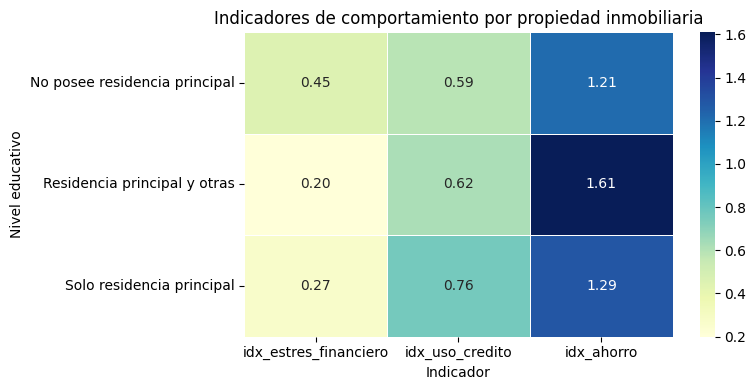

In [ ]:
heat_data = pivot_inmob.set_index("riq_inmob")[
    ["idx_estres_financiero", "idx_uso_credito", "idx_ahorro"]
]

plt.figure(figsize=(8, 4))

sns.heatmap(
    heat_data,
    annot=True,
    cmap="YlGnBu",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Indicadores de comportamiento por propiedad inmobiliaria")
plt.ylabel("Nivel educativo")
plt.xlabel("Indicador")
plt.tight_layout()
plt.show()

### 3.7. Ponderación de índices

In [ ]:
def weighted_mean(series, weights):
    return (series * weights).sum() / weights.sum()


def make_weighted_pivot(df, group_col, weight_col):

    result = []

    for group_value, group_df in df.groupby(group_col):

        weights = group_df[weight_col]

        row = {
            group_col: group_value,
            "idx_estres_financiero": weighted_mean(group_df["idx_estres_financiero"], weights),
            "idx_uso_credito": weighted_mean(group_df["idx_uso_credito"], weights),
            "idx_ahorro": weighted_mean(group_df["idx_ahorro"], weights),
            "N_muestral": len(group_df),
            "N_ponderado": weights.sum()
        }

        result.append(row)

    return pd.DataFrame(result).round(3)


In [ ]:
pivot_educ_w = make_weighted_pivot(work, "cat_educacion", "weight")
display(pivot_educ_w)

,cat_educacion,idx_estres_financiero,idx_uso_credito,idx_ahorro,N_muestral,N_ponderado
0,Educación Primaria,0.390,0.594,0.901,2514,1.474152e+07
1,Educación Secundaria,0.334,0.676,1.360,1884,8.228664e+06
2,Universidad,0.219,0.750,1.760,3156,1.207886e+07


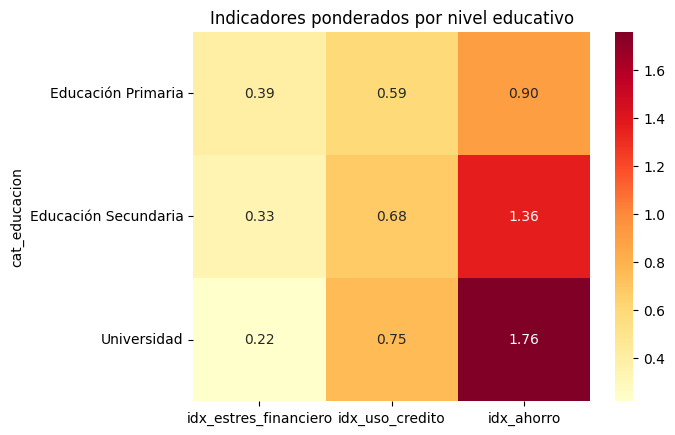

In [ ]:
heat_data = pivot_educ_w.set_index("cat_educacion")[
    ["idx_estres_financiero", "idx_uso_credito", "idx_ahorro"]
]

sns.heatmap(
    heat_data,
    annot=True,
    cmap="YlOrRd",
    fmt=".2f"
)

plt.title("Indicadores ponderados por nivel educativo")
plt.show()

In [ ]:
pivot_laboral_w = make_weighted_pivot(work, "estado_laboral", "weight")
display(pivot_laboral_w)

,estado_laboral,idx_estres_financiero,idx_uso_credito,idx_ahorro,N_muestral,N_ponderado
0,Asalariado,0.299,0.877,1.496,3733,1.632615e+07
1,Autónomo,0.326,0.814,1.582,844,3.566395e+06
2,Desempleado,0.527,0.504,0.950,780,3.836572e+06
3,Jubilado,0.215,0.401,1.105,1060,5.536234e+06
4,Otros inactivos,0.326,0.344,1.020,1137,5.783699e+06


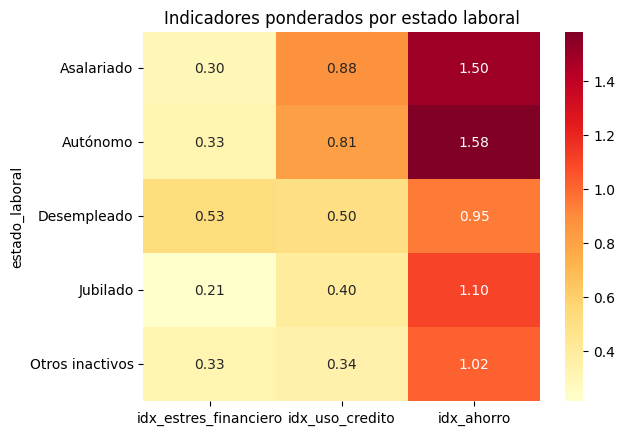

In [ ]:
heat_data = pivot_laboral_w.set_index("estado_laboral")[
    ["idx_estres_financiero", "idx_uso_credito", "idx_ahorro"]
]

sns.heatmap(
    heat_data,
    annot=True,
    cmap="YlOrRd",
    fmt=".2f"
)

plt.title("Indicadores ponderados por estado laboral")
plt.show()

In [ ]:
pivot_familia_w = make_weighted_pivot(work, "familia", "weight")
display(pivot_familia_w)

,familia,idx_estres_financiero,idx_uso_credito,idx_ahorro,N_muestral,N_ponderado
0,Otros adultos,0.318,0.397,1.212,1787,8.037777e+06
1,Vive con pareja,0.320,0.775,1.335,4812,2.259480e+07
2,Vive solo,0.309,0.604,1.320,955,4.416471e+06


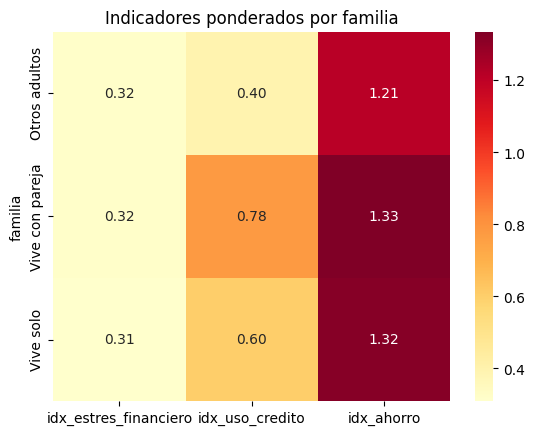

In [ ]:
heat_data = pivot_familia_w.set_index("familia")[
    ["idx_estres_financiero", "idx_uso_credito", "idx_ahorro"]
]

sns.heatmap(
    heat_data,
    annot=True,
    cmap="YlOrRd",
    fmt=".2f"
)

plt.title("Indicadores ponderados por familia")
plt.show()

In [ ]:
pivot_inmob_w = make_weighted_pivot(work, "riq_inmob", "weight")
display(pivot_inmob_w)

,riq_inmob,idx_estres_financiero,idx_uso_credito,idx_ahorro,N_muestral,N_ponderado
0,No posee residencia principal,0.488,0.608,1.125,1748,8.730344e+06
1,Residencia principal y otras,0.214,0.626,1.546,2847,1.221191e+07
2,Solo residencia principal,0.303,0.739,1.207,2959,1.410679e+07


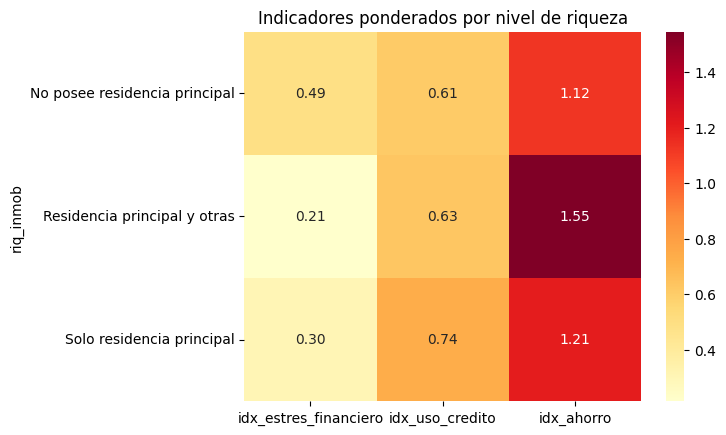

In [ ]:
heat_data = pivot_inmob_w.set_index("riq_inmob")[
    ["idx_estres_financiero", "idx_uso_credito", "idx_ahorro"]
]

sns.heatmap(
    heat_data,
    annot=True,
    cmap="YlOrRd",
    fmt=".2f"
)

plt.title("Indicadores ponderados por nivel de riqueza")
plt.show()

## 4. Indicador de vulnerabilidad
- Uso de préstamos para cubrir gastos
- Morosidad
- Denegaciones de préstamos

Objetivo: Comprender las limitaciones de solvencia y estabilidad financiera.

In [ ]:
# VARIABLES DE VULNERABILIDAD

# 1. Uso de préstamos para cubrir gastos
df["prestamo_gastos"] = (
    (df["cred_inf"] == 1) |
    (df["cred_form"] == 1) |
    (df["cred_add"] == 1)
).astype(int)

# 2. Morosidad
df["morosidad"] = (df["impago"] == 1).astype(int)

# 3. Denegación de crédito
df["denegacion_credito"] = (
    (df["rechazo"] == 1) |
    (df["semirechazo"] == 1)
).astype(int)

# 4. Uso de ahorros para cubrir gastos
df["uso_ahorros"] = (df["consumo_ahorros"] == 1).astype(int)


# CÁLCULO DEL INDICADOR DE VULNERABILIDAD (1 si cumple al menos una condición)

df["vulnerabilidad"] = (
    (df["prestamo_gastos"] == 1) |
    (df["morosidad"] == 1) |
    (df["denegacion_credito"] == 1) |
    (df["uso_ahorros"] == 1)
).astype(int)


# CHECK

df[[
    "prestamo_gastos",
    "morosidad",
    "denegacion_credito",
    "uso_ahorros",
    "vulnerabilidad"
]].mean().round(3)

prestamo_gastos       0.101
morosidad             0.027
denegacion_credito    0.044
uso_ahorros           0.132
vulnerabilidad        0.235
dtype: float64

In [ ]:
resumen_vuln = pd.DataFrame({
    "conteo": df["vulnerabilidad"].value_counts().sort_index(),
    "proporcion": df["vulnerabilidad"].value_counts(normalize=True).sort_index()
})

resumen_vuln.round(3)


,conteo,proporcion
vulnerabilidad,,
0,5780,0.765
1,1774,0.235


In [ ]:
df["vulnerabilidad"].describe()

count    7554.000000
mean        0.234842
std         0.423928
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max         1.000000
Name: vulnerabilidad, dtype: float64

### 4.1 Vulnerabilidad por nivel educativo

In [ ]:
vuln_edu = pd.crosstab(
    df["cat_educacion"],
    df["vulnerabilidad"],
    normalize="index"
).round(2)

vuln_edu



vulnerabilidad,0,1
cat_educacion,,
Educación Primaria,0.69,0.31
Educación Secundaria,0.75,0.25
Universidad,0.84,0.16


In [ ]:
vuln_edu = pd.crosstab(
    df["cat_educacion"],
    df["vulnerabilidad"],
    values=df["weight"],
    aggfunc="sum",
    normalize="index"
).round(2)

vuln_edu


vulnerabilidad,0,1
cat_educacion,,
Educación Primaria,0.68,0.32
Educación Secundaria,0.72,0.28
Universidad,0.82,0.18


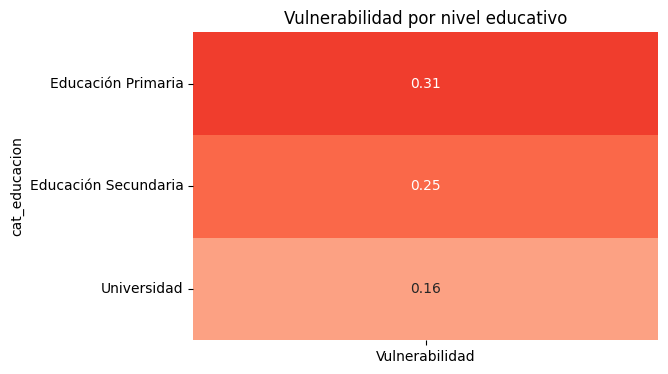

In [ ]:
tabla_edu = pd.crosstab(
    df["cat_educacion"],
    df["vulnerabilidad"],
    normalize="index"
)[1]

tabla_edu = tabla_edu.to_frame(name="Vulnerabilidad")

plt.figure(figsize=(6,4))
sns.heatmap(
    tabla_edu,
    annot=True,
    cmap="Reds",
    vmin=0,
    vmax=0.5,
    cbar=False
)

plt.title("Vulnerabilidad por nivel educativo")
plt.show()



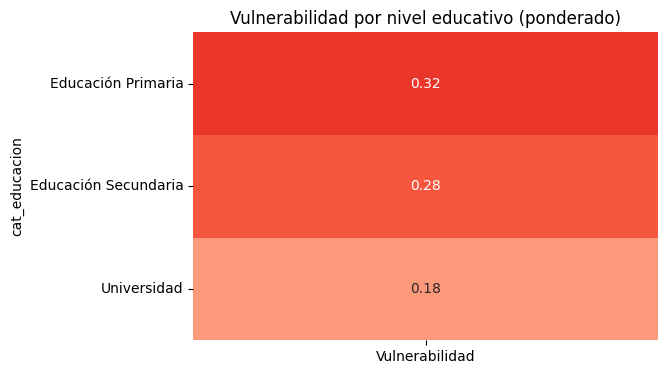

In [ ]:
tabla_edu = pd.crosstab(
    df["cat_educacion"],
    df["vulnerabilidad"],
    values=df["weight"],
    aggfunc="sum",
    normalize="index"
)[1]

tabla_edu = tabla_edu.to_frame(name="Vulnerabilidad")

plt.figure(figsize=(6,4))
sns.heatmap(
    tabla_edu,
    annot=True,
    cmap="Reds",
    vmin=0,
    vmax=0.5,
    cbar=False
)

plt.title("Vulnerabilidad por nivel educativo (ponderado)")
plt.show()


### 4.2. Vulnerabilidad por situación laboral

In [ ]:
pd.crosstab(
    df["estado_laboral"],
    df["vulnerabilidad"],
    values=df["weight"],
    aggfunc="sum",
    normalize="index"
).round(2)


vulnerabilidad,0,1
estado_laboral,,
Asalariado,0.76,0.24
Autónomo,0.73,0.27
Desempleado,0.59,0.41
Jubilado,0.81,0.19
Otros inactivos,0.73,0.27


In [2]:
pd.crosstab(
    df["estado_laboral"],
    df["vulnerabilidad"],
    normalize="index"
).round(2)

NameError: name 'pd' is not defined

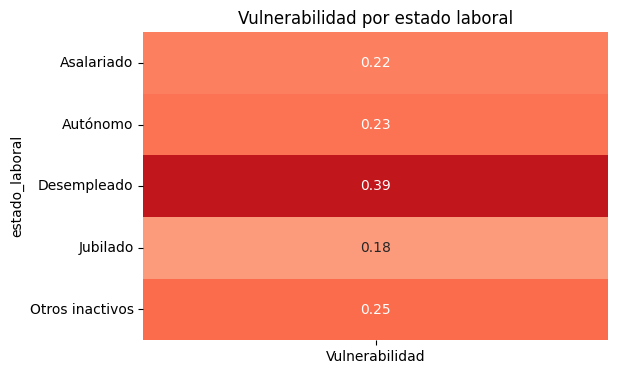

In [ ]:
tabla_lab = pd.crosstab(
    df["estado_laboral"],
    df["vulnerabilidad"],
    normalize="index"
)[1]

tabla_lab = tabla_lab.to_frame(name="Vulnerabilidad")

plt.figure(figsize=(6,4))
sns.heatmap(
    tabla_lab,
    annot=True,
    cmap="Reds",
    vmin=0,
    vmax=0.5,
    cbar=False
)

plt.title("Vulnerabilidad por estado laboral")
plt.show()


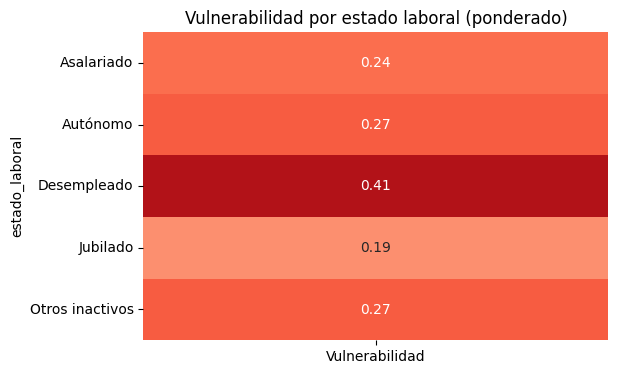

In [ ]:
tabla_lab = pd.crosstab(
    df["estado_laboral"],
    df["vulnerabilidad"],
    values=df["weight"],
    aggfunc="sum",
    normalize="index"
)[1]

tabla_lab = tabla_lab.to_frame(name="Vulnerabilidad")

plt.figure(figsize=(6,4))
sns.heatmap(
    tabla_lab,
    annot=True,
    cmap="Reds",
    vmin=0,
    vmax=0.5,
    cbar=False
)

plt.title("Vulnerabilidad por estado laboral (ponderado)")
plt.show()


### 4.3. Vulnerabilidad por tipo de unidad familiar


In [ ]:
pd.crosstab(
    df["familia"],
    df["vulnerabilidad"],
    values=df["weight"],
    aggfunc="sum",
    normalize="index"
).round(2)


vulnerabilidad,0,1
familia,,
Otros adultos,0.74,0.26
Vive con pareja,0.74,0.26
Vive solo,0.74,0.26


### 4.4. Vulnerabilidad por edad

In [ ]:
vuln_age = pd.crosstab(
    df["age"],
    df["vulnerabilidad"],
    normalize="index"
).round(2)

vuln_age


vulnerabilidad,0,1
age,,
18,0.73,0.27
19,0.81,0.19
20,0.83,0.17
21,0.82,0.18
22,0.79,0.21
...,...,...
76,0.78,0.22
77,0.86,0.14
78,0.92,0.08


In [ ]:
vuln_age = pd.crosstab(
    df["age"],
    df["vulnerabilidad"],
    values=df["weight"],
    aggfunc="sum",
    normalize="index"
).round(3)

vuln_age


vulnerabilidad,0,1
age,,
18,0.704,0.296
19,0.767,0.233
20,0.828,0.172
21,0.810,0.190
22,0.776,0.224
...,...,...
76,0.762,0.238
77,0.880,0.120
78,0.906,0.094


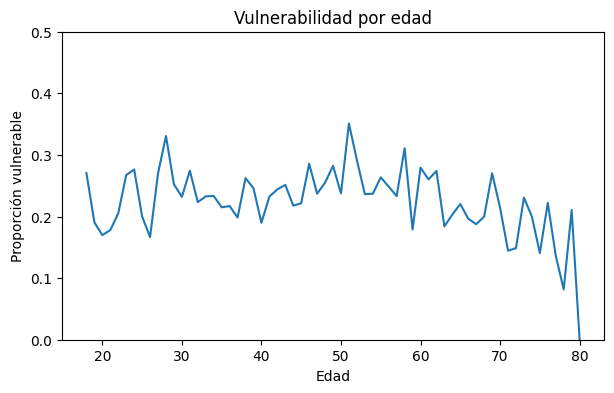

In [ ]:
tabla_age = pd.crosstab(
    df["age"],
    df["vulnerabilidad"],
    normalize="index"
)[1]

plt.figure(figsize=(7,4))
plt.plot(tabla_age.index, tabla_age.values)

plt.title("Vulnerabilidad por edad")
plt.xlabel("Edad")
plt.ylabel("Proporción vulnerable")
plt.ylim(0, 0.5)

plt.show()


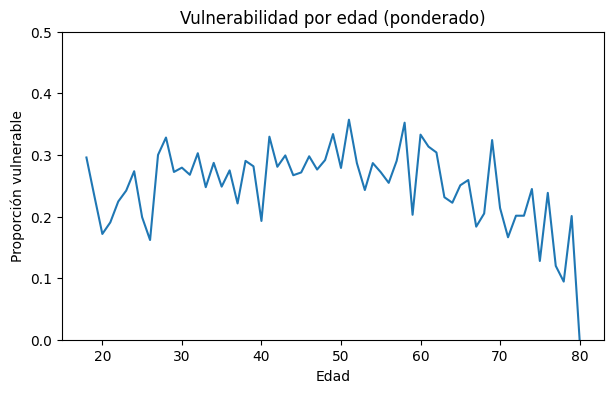

In [ ]:
tabla_age = pd.crosstab(
    df["age"],
    df["vulnerabilidad"],
    values=df["weight"],
    aggfunc="sum",
    normalize="index"
)[1]

plt.figure(figsize=(7,4))
plt.plot(tabla_age.index, tabla_age.values)

plt.title("Vulnerabilidad por edad (ponderado)")
plt.xlabel("Edad")
plt.ylabel("Proporción vulnerable")
plt.ylim(0, 0.5)

plt.show()


### 4.5. Vulnerabilidad por Competencia financiera